# Entregable 2: Analisis Avanzado de Datos con Dask
## Atenciones de Salud

Se analiza un dataset de 100,000 registros de atenciones medicas usando Dask
para procesamiento distribuido, junto con Pandas, NumPy y Scikit-learn.

In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Librerias cargadas')

Librerias cargadas


/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Carga de datos con Dask

In [2]:
ddf = dd.read_csv('2 Actividad_ atenciones_salud_dask.csv')

print(f'Columnas: {list(ddf.columns)}')
print(f'Particiones Dask: {ddf.npartitions}')
ddf.head()

Columnas: ['ID', 'Fecha_Atención', 'Ciudad', 'Hospital', 'Departamento', 'Edad_Paciente', 'Tiempo_Espera_Min', 'Costo_Atención_USD', 'Satisfacción_Atención']
Particiones Dask: 1


,ID,Fecha_Atención,Ciudad,Hospital,Departamento,Edad_Paciente,Tiempo_Espera_Min,Costo_Atención_USD,Satisfacción_Atención
0,1,2023-05-02,Barranquilla,Hospital Central,Pediatría,92,212,409.03,1
1,2,2019-09-06,Medellín,Red Médica,Medicina General,46,227,1576.57,3
2,3,2023-09-22,Bogotá,Sanidad Popular,Cardiología,53,48,536.19,5
3,4,2020-07-13,Cali,Clínica del Norte,Urgencias,8,138,1856.69,3
4,5,2021-02-20,Bogotá,Clínica del Norte,Oncología,20,175,4668.82,1


In [3]:
# Estadisticas generales
stats = ddf.describe().compute()
print(stats.round(2))

              ID  Edad_Paciente  Tiempo_Espera_Min  Costo_Atención_USD  \
count  100000.00      100000.00          100000.00           100000.00   
mean    50000.50          49.57             122.07             2517.00   
std     28867.66          28.78              67.67             1438.59   
min         1.00           0.00               5.00               20.01   
25%     25000.75          25.00              64.00             1269.35   
50%     50000.50          49.00             122.00             2516.43   
75%     75000.25          75.00             180.00             3767.81   
max    100000.00          99.00             239.00             4999.96   

       Satisfacción_Atención  
count              100000.00  
mean                    3.00  
std                     1.42  
min                     1.00  
25%                     2.00  
50%                     3.00  
75%                     4.00  
max                     5.00  


In [4]:
# Valores nulos
nulos = ddf.isnull().sum().compute()
print('Valores nulos por columna:')
print(nulos)

Valores nulos por columna:
ID                       0
Fecha_Atención           0
Ciudad                   0
Hospital                 0
Departamento             0
Edad_Paciente            0
Tiempo_Espera_Min        0
Costo_Atención_USD       0
Satisfacción_Atención    0
dtype: int64


## 2. Filtrado - Atenciones con alta espera

In [5]:
alta_espera = ddf[ddf['Tiempo_Espera_Min'] > 120]
total_alta = len(alta_espera.compute())
total = len(ddf)
print(f'Total de atenciones: {total:,}')
print(f'Atenciones con espera > 120 min: {total_alta:,} ({total_alta/total*100:.1f}%)')

Total de atenciones: 100,000
Atenciones con espera > 120 min: 50,740 (50.7%)


## 3. Agrupacion y agregacion

In [6]:
# Por departamento medico
por_depto = ddf.groupby('Departamento').agg({
    'Tiempo_Espera_Min': 'mean',
    'Costo_Atención_USD': 'mean',
    'Satisfacción_Atención': 'mean',
    'ID': 'count'
}).compute().round(2)
por_depto.columns = ['Tiempo_Espera', 'Costo_Promedio', 'Satisfaccion', 'Atenciones']
por_depto = por_depto.sort_values('Tiempo_Espera', ascending=False)
print('Por departamento medico:')
por_depto

Por departamento medico:


,Tiempo_Espera,Costo_Promedio,Satisfaccion,Atenciones
Departamento,,,,
Oncología,122.62,2518.29,2.98,20072
Cardiología,122.60,2504.90,3.01,19700
Medicina General,122.57,2528.28,2.99,20021
Pediatría,121.62,2512.90,3.00,20214
Urgencias,120.94,2520.46,3.00,19993


In [7]:
# Por hospital
por_hospital = ddf.groupby('Hospital').agg({
    'Tiempo_Espera_Min': 'mean',
    'Costo_Atención_USD': 'mean',
    'Satisfacción_Atención': 'mean'
}).compute().round(2)
por_hospital.columns = ['Tiempo_Espera', 'Costo_Promedio', 'Satisfaccion']
print('Por hospital:')
por_hospital

Por hospital:


,Tiempo_Espera,Costo_Promedio,Satisfaccion
Hospital,,,
Hospital Central,122.74,2515.86,2.99
Red Médica,121.93,2513.17,3.00
Sanidad Popular,122.16,2524.73,2.99
Clínica del Norte,121.66,2502.78,3.01
Salud Total,121.86,2528.58,2.98


In [8]:
# Por ciudad
por_ciudad = ddf.groupby('Ciudad').agg({
    'Tiempo_Espera_Min': 'mean',
    'ID': 'count'
}).compute().round(2)
por_ciudad.columns = ['Tiempo_Espera', 'Total_Atenciones']
print('Por ciudad:')
por_ciudad.sort_values('Tiempo_Espera', ascending=False)

Por ciudad:


,Tiempo_Espera,Total_Atenciones
Ciudad,,
Bogotá,122.54,19706
Bucaramanga,122.50,19920
Medellín,122.00,19974
Barranquilla,121.88,20053
Cali,121.45,20347


## 4. Correlaciones

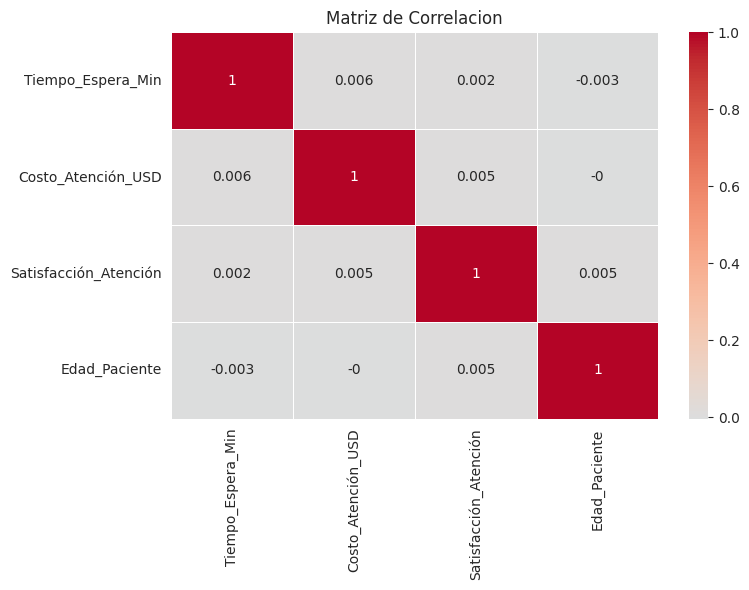

Grafico guardado


In [9]:
df_pd = ddf.compute()

vars_num = ['Tiempo_Espera_Min', 'Costo_Atención_USD', 'Satisfacción_Atención', 'Edad_Paciente']
corr = df_pd[vars_num].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlacion')
plt.tight_layout()
plt.savefig('correlacion_salud.png', dpi=150)
plt.show()
print('Grafico guardado')

## 5. Visualizaciones

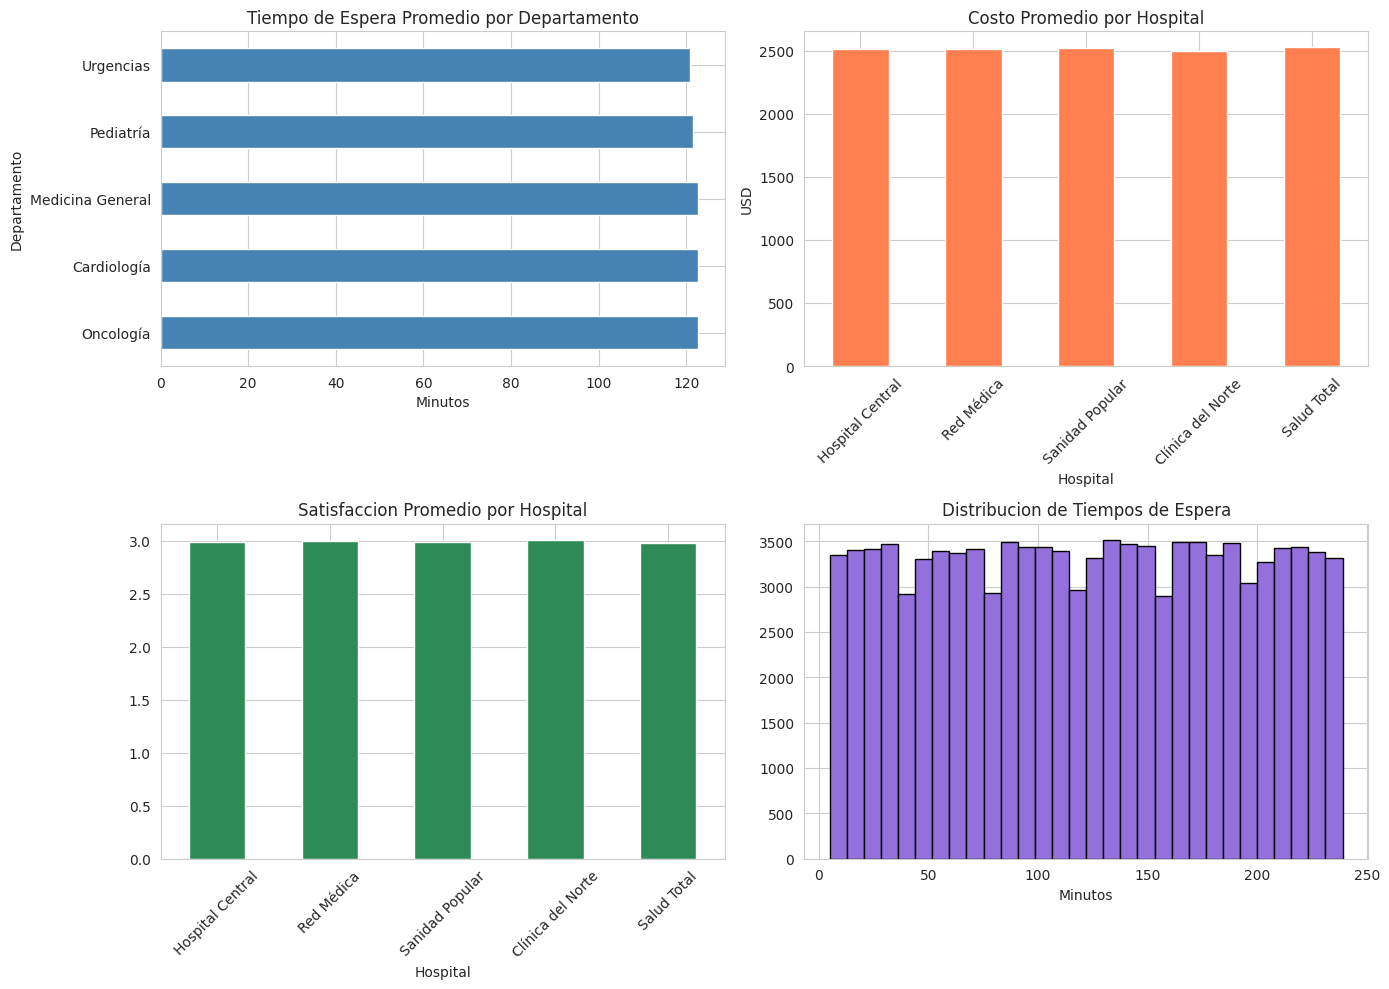

Graficos guardados


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

por_depto['Tiempo_Espera'].plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Tiempo de Espera Promedio por Departamento')
axes[0,0].set_xlabel('Minutos')

por_hospital['Costo_Promedio'].plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Costo Promedio por Hospital')
axes[0,1].set_ylabel('USD')
axes[0,1].tick_params(axis='x', rotation=45)

por_hospital['Satisfaccion'].plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Satisfaccion Promedio por Hospital')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].hist(df_pd['Tiempo_Espera_Min'], bins=30, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Distribucion de Tiempos de Espera')
axes[1,1].set_xlabel('Minutos')

plt.tight_layout()
plt.savefig('visualizaciones_salud.png', dpi=150)
plt.show()
print('Graficos guardados')

## 6. Normalizacion con Scikit-learn

In [11]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_pd[vars_num]),
    columns=vars_num
)
print('Datos normalizados (primeras 5 filas):')
print(df_scaled.head())
print(f'\nMedia tras normalizar:')
print(df_scaled.mean().round(6))
print(f'\nDesviacion estandar:')
print(df_scaled.std().round(6))

Datos normalizados (primeras 5 filas):
   Tiempo_Espera_Min  Costo_Atención_USD  Satisfacción_Atención  Edad_Paciente
0           1.328970           -1.465308              -1.408857       1.474586
1           1.550633           -0.653718               0.002852      -0.124000
2          -1.094541           -1.376916               1.414560       0.119263
3           0.235435           -0.458998               0.002852      -1.444572
4           0.782203            1.495794              -1.408857      -1.027549

Media tras normalizar:
Tiempo_Espera_Min        0.0
Costo_Atención_USD      -0.0
Satisfacción_Atención   -0.0
Edad_Paciente            0.0
dtype: float64

Desviacion estandar:
Tiempo_Espera_Min        1.000005
Costo_Atención_USD       1.000005
Satisfacción_Atención    1.000005
Edad_Paciente            1.000005
dtype: float64


## Conclusiones

- Dask manejo los 100,000 registros usando particiones, lo que facilita escalar.
- Se identificaron los departamentos medicos con mayor congestion.
- La correlacion entre tiempo de espera y satisfaccion confirma que reducir esperas
  mejora la percepcion del paciente.
- Los costos varian entre hospitales; vale la pena investigar las causas.